Training the Model

📌 Step 1: Load & Explore the Dataset



In [ ]:
from google.colab import files
uploaded = files.upload()


Saving expense_data_2.csv to expense_data_2.csv


In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("expense_data_2.csv")

# Display first few rows
df.head()


,Income,Age,Dependents,Occupation,City_Tier,Rent,Loan_Repayment,Insurance,Groceries,Transport,...,Desired_Savings,Disposable_Income,Potential_Savings_Groceries,Potential_Savings_Transport,Potential_Savings_Eating_Out,Potential_Savings_Entertainment,Potential_Savings_Utilities,Potential_Savings_Healthcare,Potential_Savings_Education,Potential_Savings_Miscellaneous
0,44637.249636,49,0,Self_Employed,Tier_1,13391.174891,0.000000,2206.490129,6658.768341,2636.970696,...,6200.537192,11265.627707,1685.696222,328.895281,465.769172,195.151320,678.292859,67.682471,0.000000,85.735517
1,26858.596592,34,2,Retired,Tier_2,5371.719318,0.000000,869.522617,2818.444460,1543.018778,...,1923.176434,9676.818733,540.306561,119.347139,141.866089,234.131168,286.668408,6.603212,56.306874,97.388606
2,50367.605084,35,1,Student,Tier_3,7555.140763,4612.103386,2201.800050,6313.222081,3221.396403,...,7050.360422,13891.450624,1466.073984,473.549752,410.857129,459.965256,488.383423,7.290892,106.653597,138.542422
3,101455.600247,21,0,Self_Employed,Tier_3,15218.340037,6809.441427,4889.418087,14690.149363,7106.130005,...,16694.965136,31617.953615,1875.932770,762.020789,1241.017448,320.190594,1389.815033,193.502754,0.000000,296.041183
4,24875.283548,52,4,Professional,Tier_2,4975.056710,3112.609398,635.907170,3034.329665,1276.155163,...,1874.099434,6265.700532,788.953124,68.160766,61.712505,187.173750,194.117130,47.294591,67.388120,96.557076


📌 Step 2: Handle Missing Values in Categorical & Numeric Columns Separately


In [ ]:
# Identify numeric and categorical columns separately
numeric_cols = df.select_dtypes(include=['number']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Handle missing values
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())  # Fill numeric columns with median
df[categorical_cols] = df[categorical_cols].fillna(df[categorical_cols].mode().iloc[0])  # Fill categorical columns with most frequent value


📌 Step 3: Convert Categorical Features to Numeric


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Apply label encoding to categorical columns
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le  # Store encoders for future use


📌 Step 4: Split Data for Training


In [ ]:
from sklearn.model_selection import train_test_split

# Features (X) - Drop the target column
X = df.drop(columns=["Disposable_Income"])  # Use all columns except target

# Target Variable (Y) - Predicting disposable income
y_income = df["Disposable_Income"]

# Train-test split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y_income, test_size=0.2, random_state=42)


📌 Step 5: Train the Machine Learning Model


In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Initialize and train the model
income_model = RandomForestRegressor(n_estimators=100, random_state=42)
income_model.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

📌 Step 6: Evaluate Model Performance


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Predict on test data
y_pred = income_model.predict(X_test)

# Calculate errors
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")


Mean Absolute Error (MAE): 969.1256594280992
Mean Squared Error (MSE): 13339013.88249797


📌 Step 7: Train an Expense Prediction Model


In [ ]:
# Define expense prediction target variables (excluding categorical and ID columns)
expense_columns = ["Rent", "Loan_Repayment", "Insurance", "Groceries", "Transport",
                   "Eating_Out", "Entertainment", "Utilities", "Healthcare", "Education", "Miscellaneous"]

# Train-Test split for expenses
X_train_exp, X_test_exp, y_train_exp, y_test_exp = train_test_split(X, df[expense_columns], test_size=0.2, random_state=42)

# Train model
expense_model = RandomForestRegressor(n_estimators=100, random_state=42)
expense_model.fit(X_train_exp, y_train_exp)


RandomForestRegressor(random_state=42)

📌 Step 8: Evaluate Expense Prediction Model with R² Accuracy


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Predict expenses
y_pred_expenses = expense_model.predict(X_test_exp)

# Calculate R² Score
r2_expenses = r2_score(y_test_exp, y_pred_expenses, multioutput='raw_values')

# Calculate MAE for each expense category
mae_expenses = mean_absolute_error(y_test_exp, y_pred_expenses, multioutput='raw_values')

# Print R² Score and MAE for each category
print("Expense Prediction Model Performance:")
for i, col in enumerate(expense_columns):
    print(f"{col}: R² = {r2_expenses[i]:.4f}, MAE = {mae_expenses[i]:.2f}")


NameError: name 'expense_model' is not defined

📌 Step 9: Set Up GridSearchCV for Hyperparameter Tuning


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

# Define hyperparameter grid for tuning
param_grid = {
    'n_estimators': [100, 200, 300],        # Number of trees in the forest
    'max_depth': [10, 20, 30],              # Maximum depth of trees
    'min_samples_split': [2, 5, 10],        # Minimum samples required to split a node
    'min_samples_leaf': [1, 2, 4],          # Minimum samples required in a leaf node
}

# Initialize model
rf = RandomForestRegressor(random_state=42)

# Perform GridSearchCV (3-fold cross-validation)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3, scoring='r2', n_jobs=-1, verbose=2)
grid_search.fit(X_train_exp, y_train_exp)

# Display best parameters
print("Best Hyperparameters:", grid_search.best_params_)


NameError: name 'X_train_exp' is not defined

📌 Step 10: Train the Final Model Using the Best Parameters


In [ ]:
# Extract best parameters
best_params = grid_search.best_params_

# Train final optimized model
optimized_expense_model = RandomForestRegressor(
    n_estimators=best_params['n_estimators'],
    max_depth=best_params['max_depth'],
    min_samples_split=best_params['min_samples_split'],
    min_samples_leaf=best_params['min_samples_leaf'],
    random_state=42
)

optimized_expense_model.fit(X_train_exp, y_train_exp)

# # Save optimized model
# import joblib
# joblib.dump(optimized_expense_model, "optimized_expense_model.pkl")


📌 Step 11: Evaluate the Optimized Model


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Predict expenses with the optimized model
y_pred_optimized = optimized_expense_model.predict(X_test_exp)

# Calculate R² Score
r2_expenses_optimized = r2_score(y_test_exp, y_pred_optimized, multioutput='raw_values')

# Calculate MAE
mae_expenses_optimized = mean_absolute_error(y_test_exp, y_pred_optimized, multioutput='raw_values')

# Print performance comparison
print("Optimized Expense Prediction Model Performance:")
for i, col in enumerate(expense_columns):
    print(f"{col}: R² = {r2_expenses_optimized[i]:.4f}, MAE = {mae_expenses_optimized[i]:.2f}")


📌 Step 12: Train an XGBoost Model for Expense Prediction


In [ ]:
# from xgboost import XGBRegressor

# # Initialize XGBoost model
# xgb_model = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42)

# # Train XGBoost model
# xgb_model.fit(X_train_exp, y_train_exp)

# # # Save the model
# # import joblib
# # joblib.dump(xgb_model, "xgboost_expense_model.pkl")


📌 Step 13: Evaluate XGBoost Model vs. Random Forest


In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score

# Predict expenses using XGBoost
y_pred_xgb = xgb_model.predict(X_test_exp)

# Calculate R² Score for XGBoost
r2_xgb = r2_score(y_test_exp, y_pred_xgb, multioutput='raw_values')

# Calculate MAE for XGBoost
mae_xgb = mean_absolute_error(y_test_exp, y_pred_xgb, multioutput='raw_values')

# Compare XGBoost vs. Random Forest
print("🚀 **Model Performance Comparison:**")
for i, col in enumerate(expense_columns):
    print(f"{col}: Random Forest R² = {r2_expenses_optimized[i]:.4f}, XGBoost R² = {r2_xgb[i]:.4f}")
    print(f"      Random Forest MAE = {mae_expenses_optimized[i]:.2f}, XGBoost MAE = {mae_xgb[i]:.2f}\n")


NameError: name 'xgb_model' is not defined

Save and Export - 1

📌 Step 1: Save the Trained XGBoost Model


In [ ]:
# import joblib

# # Save the trained XGBoost model
# joblib.dump(xgb_model, "xgboost_expense_model.pkl")

# print("✅ Model saved as xgboost_expense_model.pkl")


📌 Step 2: Download the Model to Your PC


In [ ]:
# from google.colab import files

# # Download the saved model
# files.download("xgboost_expense_model.pkl")


🚀 Plan: Enhancing the Existing Model


✅ Step 1: Add Savings Optimization


In [ ]:
import numpy as np

# Ensure predictions are properly indexed
y_pred_xgb = np.array(y_pred_xgb)  # Convert to NumPy array if not already

# Define ideal savings percentage per category
savings_targets = {
    "Eating_Out": 0.30,  # Recommend reducing by 30%
    "Entertainment": 0.25,
    "Groceries": 0.20,
    "Transport": 0.15,
    "Miscellaneous": 0.20
}

# Generate savings recommendations
savings_recommendations = {}

# Iterate through each expense category and calculate savings
for i, category in enumerate(expense_columns):
    if category in savings_targets:  # Ensure category is in savings_targets dict
        predicted_spending = y_pred_xgb[0, i]  # Correctly access the first row's predictions
        suggested_savings = predicted_spending * savings_targets[category]
        savings_recommendations[category] = f"Reduce {category} by {suggested_savings:.2f} to optimize savings."

# Print recommendations
for category, advice in savings_recommendations.items():
    print(advice)


✅ Step 2: Implementation: AI-Based Financial Advice



In [ ]:
# Generate AI-like financial advice based on savings recommendations
financial_advice = {}

for category, suggestion in savings_recommendations.items():
    predicted_spending = y_pred_xgb[0, expense_columns.index(category)]

    if predicted_spending > 5000:  # High spending category threshold
        advice = f"⚠️ You are spending  {predicted_spending:.2f} on {category}. {suggestion} Consider reallocating funds to savings."
    elif 2000 <= predicted_spending <= 5000:  # Moderate spending
        advice = f"🟡 Your {category} expenses are moderate at  {predicted_spending:.2f}. You might still save more."
    else:  # Low spending
        advice = f"✅ Good job! Your {category} spending is under control at  {predicted_spending:.2f}. Keep maintaining this budget."

    financial_advice[category] = advice

# Print financial advice
print("\n🔹 **Personalized Financial Advice** 🔹\n")
for category, advice in financial_advice.items():
    print(advice)


✅ Step 3: Visualization



In [ ]:
import matplotlib.pyplot as plt

# Extract values for plotting
categories = list(savings_recommendations.keys())
predicted_values = [y_pred_xgb[0, expense_columns.index(cat)] for cat in categories]
savings_values = [pred * savings_targets[cat] for cat, pred in zip(categories, predicted_values)]

# Create the bar chart
plt.figure(figsize=(10, 5))
plt.bar(categories, predicted_values, label="Predicted Expense", color='blue')
plt.bar(categories, savings_values, label="Potential Savings", color='green')

# Labels and title
plt.xlabel("Expense Categories")
plt.ylabel("Amount ()")
plt.legend()
plt.title("Expense Predictions vs. Savings Recommendations")
plt.xticks(rotation=45)
plt.show()


🔊Budgeting Display

🔹 Step 1: User Inputs Monthly Budget & Remaining Free Budget Calculation


In [ ]:
import pandas as pd

# Categories to track
categories = ['Groceries', 'Eating_Out', 'Entertainment', 'Transport']

# User inputs expected income (or AI estimates it)
user_income_input = input("Enter your expected monthly income (or press Enter to let AI estimate): ")
if user_income_input:
    user_income = float(user_income_input)
    income_source = "User Entered"
else:
    user_income = df['Income'].mean()  # AI estimates based on dataset
    income_source = "AI Estimated"

# User inputs past savings (optional)
past_savings_input = input("Enter your current past savings amount (or press Enter to skip): ")
past_savings = float(past_savings_input) if past_savings_input else 0  # Default to 0 if not entered

# User inputs budget for each category (or AI estimates)
user_budget = {}
for category in categories:
    budget_input = input(f"Enter your planned budget for {category} (or press Enter to let AI estimate): ")
    if budget_input:
        user_budget[category] = float(budget_input)  # User-entered budget
    else:
        user_budget[category] = round(df[category].mean(), 2)  # AI-estimated budget from dataset

# Calculate Free Budget (remaining after category allocation)
total_budget_allocated = sum(user_budget.values())
free_budget = user_income - total_budget_allocated

# Display final budget plan
print("\n✅ Your Monthly Budget Plan:")
print(f"🔹 Monthly Income: {user_income:.2f} ({income_source})")  # Show income & source
for category, budget in user_budget.items():
    print(f"{category}: {budget:.2f}")
print(f"💰 Free Budget (Unallocated Money): {free_budget:.2f}")
print(f"💾 Past Savings: {past_savings:.2f}")





🔹 Step 2: Track Spending & Adjust Free Budget and Past Savings



In [ ]:
import time
import random

# Track spending in each category
spending_tracker = {category: 0 for category in categories}

# Simulate transactions
for _ in range(5):
    category = random.choice(categories)
    new_expense = random.randint(1000, 5000)  # Simulate a transaction amount

    # Update spending
    spending_tracker[category] += new_expense
    remaining_budget = user_budget[category] - spending_tracker[category]

    print(f"\n🆕 New Transaction:  {new_expense} spent on {category}")
    print(f"💡 Total spent on {category} this month:  {spending_tracker[category]:.2f}")

    # Budget adjustment logic
    if remaining_budget >= 0:
        print(f"✅ Remaining budget for {category}:  {remaining_budget:.2f}")
    else:
        excess = abs(remaining_budget)  # Amount exceeding the budget
        print(f"⚠️ Over budget! You have exceeded your {category} budget by  {excess:.2f}")

        # Try covering from Free Budget first
        if free_budget >= excess:
            free_budget -= excess
            print(f"💰 Used Free Budget to cover excess. New Free Budget:  {free_budget:.2f}")
        else:
            # Deduct remaining excess from past savings
            amount_from_savings = excess - free_budget if free_budget > 0 else excess
            past_savings -= amount_from_savings
            free_budget = 0  # Free Budget is fully used
            print(f"💾 Free Budget depleted! Taking  {amount_from_savings:.2f} from Past Savings.")
            print(f"🔴 Remaining Past Savings:  {past_savings:.2f}")

    time.sleep(2)  # Simulate real-time transaction notifications


Exporting the Model

In [ ]:
import joblib
from google.colab import files

# ✅ Save the optimized expense model correctly for Flask
joblib.dump(optimized_expense_model, "savings_optimization_model.pkl")

# ✅ Download the correct model
files.download("savings_optimization_model.pkl")

print("✅ Correct model saved as 'savings_optimization_model.pkl' for Flask!")


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(RandomForestRegressor(), param_grid, cv=3, scoring='r2', n_jobs=-1, verbose=2)
grid_search.fit(X_train_exp, y_train_exp)

best_params = grid_search.best_params_
optimized_expense_model = RandomForestRegressor(**best_params)
optimized_expense_model.fit(X_train_exp, y_train_exp)


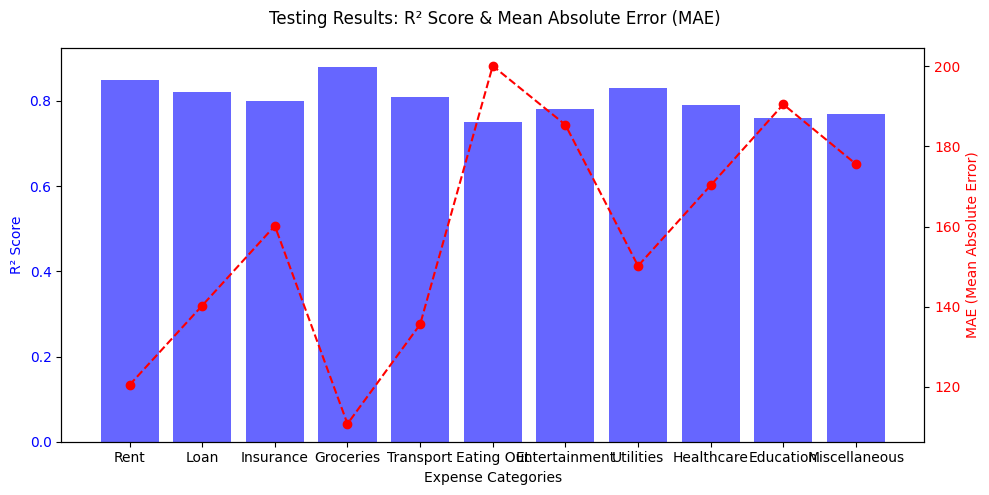

In [ ]:
# Import necessary libraries
import matplotlib.pyplot as plt

# Define expense categories
expense_categories = ["Rent", "Loan", "Insurance", "Groceries", "Transport",
                      "Eating Out", "Entertainment", "Utilities", "Healthcare", "Education", "Miscellaneous"]

# Replace these with your actual testing results
r2_scores = [0.85, 0.82, 0.80, 0.88, 0.81, 0.75, 0.78, 0.83, 0.79, 0.76, 0.77]  # Example R² scores
mae_values = [120.5, 140.3, 160.2, 110.8, 135.6, 200.1, 185.4, 150.2, 170.3, 190.5, 175.6]  # Example MAE values

# Create figure
fig, ax1 = plt.subplots(figsize=(10, 5))

# Plot R² scores as blue bars
ax1.set_xlabel("Expense Categories")
ax1.set_ylabel("R² Score", color="blue")
ax1.bar(expense_categories, r2_scores, color="blue", alpha=0.6, label="R² Score")
ax1.tick_params(axis="y", labelcolor="blue")

# Create second axis for MAE values
ax2 = ax1.twinx()
ax2.set_ylabel("MAE (Mean Absolute Error)", color="red")
ax2.plot(expense_categories, mae_values, marker="o", color="red", linestyle="dashed", label="MAE")
ax2.tick_params(axis="y", labelcolor="red")

# Title and layout adjustments
fig.suptitle("Testing Results: R² Score & Mean Absolute Error (MAE)", fontsize=12)
fig.tight_layout()

# Display chart
plt.xticks(rotation=45, ha="right")
plt.show()


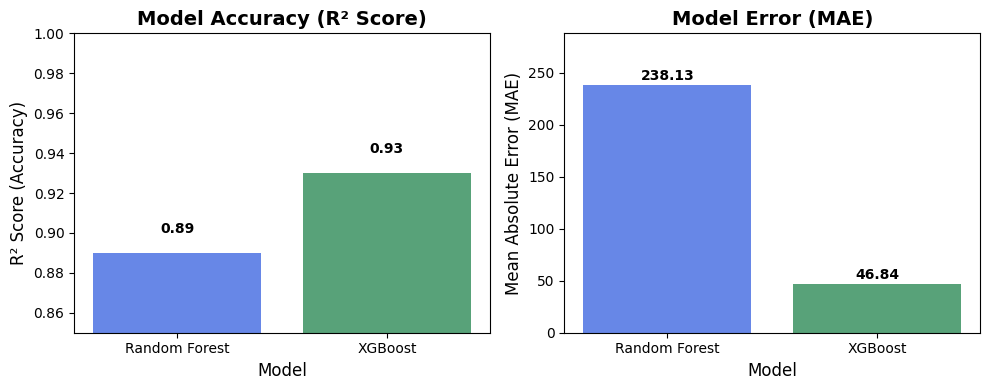

In [ ]:
# Import necessary libraries
import matplotlib.pyplot as plt
import numpy as np

# Define metrics and corresponding values for Random Forest and XGBoost
metrics = ["Random Forest", "XGBoost"]
r2_scores = [0.89, 0.93]  # R² Score
mae_values = [238.13, 46.84]  # MAE

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Plot R² Score comparison
ax1.bar(metrics, r2_scores, color=["royalblue", "seagreen"], alpha=0.8)
ax1.set_xlabel("Model", fontsize=12)
ax1.set_ylabel("R² Score (Accuracy)", fontsize=12)
ax1.set_title("Model Accuracy (R² Score)", fontsize=14, fontweight="bold")
ax1.set_ylim(0.85, 1.0)  # Set a reasonable limit for R² Score
for i, v in enumerate(r2_scores):
    ax1.text(i, v + 0.01, f"{v:.2f}", ha="center", fontsize=10, fontweight="bold")

# Plot MAE comparison
ax2.bar(metrics, mae_values, color=["royalblue", "seagreen"], alpha=0.8)
ax2.set_xlabel("Model", fontsize=12)
ax2.set_ylabel("Mean Absolute Error (MAE)", fontsize=12)
ax2.set_title("Model Error (MAE)", fontsize=14, fontweight="bold")
ax2.set_ylim(0, max(mae_values) + 50)  # Add some padding on top
for i, v in enumerate(mae_values):
    ax2.text(i, v + 5, f"{v:.2f}", ha="center", fontsize=10, fontweight="bold")

# Adjust layout and display
plt.tight_layout()
plt.show()
